# Basic Neural Network

Phân loại ảnh thành 4 lớp: fire, nofire, smoke và smokefire.

1. Import thư viện và cấu hình
2. Nạp dữ liệu và xử lý ảnh
3. Xây dựng mạng Dense
4. Huấn luyện
5. Đánh giá trên tập test
6. Lưu kết quả

## Bước 1 – Import thư viện và cấu hình

Đặt kích thước ảnh, batch size, số epoch và đường dẫn lưu kết quả. Seed 42 giúp hạn chế khác biệt giữa các lần chạy.

In [1]:
from pathlib import Path
import json
import tensorflow as tf
from tensorflow.keras import layers, callbacks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

ROOT = Path.cwd() if (Path.cwd() / 'notebooks').exists() else Path.cwd().parent
CLASS_NAMES = ['fire', 'nofire', 'smoke', 'smokefire']
IMAGE_SIZE = (64, 64)
BATCH_SIZE = 32
EPOCHS = 30
SEED = 42
RESULT_DIR = ROOT / 'results/basic_nn_transfer_preprocessing'
MODEL_PATH = ROOT / 'models/basic_nn_transfer_preprocessing.keras'
RESULT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH.parent.mkdir(exist_ok=True)
tf.keras.utils.set_random_seed(SEED)
print('TensorFlow:', tf.__version__)

TensorFlow: 2.21.0


## Bước 2 – Nạp dữ liệu và xử lý ảnh

Đọc `data/split.csv`, lấy các ảnh có trạng thái `ok` và kiểm tra nhãn khớp với class index.

- Ảnh processed là RGB 224×224, đã chỉnh hướng theo EXIF.
- Thu nhỏ xuống 64×64 để giảm số tham số khi Flatten.
- Chuẩn hóa `(pixel / 255 - mean) / std` bằng mean/std ImageNet, giống phần transfer learning.
- Train được shuffle; validation và test giữ thứ tự để đối chiếu dự đoán với nhãn thật.

In [2]:
df = pd.read_csv(ROOT / 'data/split.csv')
df = df[df['status'] == 'ok'].copy()
assert (df['label'].map({name: i for i, name in enumerate(CLASS_NAMES)}) == df['class_index']).all()
assert set(df['split']) == {'train', 'val', 'test'}
display(pd.crosstab(df['split'], df['label'])[CLASS_NAMES])

label,fire,nofire,smoke,smokefire
split,,,,
test,200,200,200,200
train,800,800,800,800
val,200,200,200,200


In [3]:
def load_image(filepath, label):
    image = tf.io.decode_jpeg(tf.io.read_file(filepath), channels=3)
    image = tf.ensure_shape(image, [224, 224, 3])
    image = tf.image.resize(image, IMAGE_SIZE, antialias=True) / 255.0
    image = (image - [0.485, 0.456, 0.406]) / [0.229, 0.224, 0.225]
    return image, label


def make_dataset(split, shuffle=False):
    part = df[df['split'] == split].reset_index(drop=True)
    paths = [str(ROOT / p) for p in part['processed_filepath']]
    assert paths and all(Path(p).is_file() for p in paths), 'Thiếu ảnh processed.'
    ds = tf.data.Dataset.from_tensor_slices((paths, part['class_index'].astype('int32')))
    if shuffle:
        ds = ds.shuffle(len(part), seed=SEED)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


train_ds = make_dataset('train', shuffle=True)
val_ds = make_dataset('val')
test_ds = make_dataset('test')
test_df = df[df['split'] == 'test'].reset_index(drop=True)

## Bước 3 – Xây dựng mạng Dense

Lật ngang ảnh khi train → Flatten → Dense(256) → BatchNormalization → ReLU → Dropout(0,3) → Dense(128, ReLU) → Dropout(0,2) → Dense(4, Softmax).

Flatten chuyển ảnh thành vector. Hai lớp Dense học đặc trưng để phân loại; BatchNormalization ổn định giá trị trước ReLU, Dropout hạn chế overfitting. Softmax trả về xác suất của 4 lớp.

Dùng Adam với learning rate 0,0003. Nhãn là số nguyên nên loss dùng `sparse_categorical_crossentropy`.

In [4]:
model = tf.keras.Sequential([
    layers.Input(shape=(*IMAGE_SIZE, 3)),
    layers.RandomFlip('horizontal', seed=SEED),
    layers.Flatten(),
    layers.Dense(256, use_bias=False, kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu', kernel_initializer='he_normal'),
    layers.Dropout(0.2),
    layers.Dense(len(CLASS_NAMES), activation='softmax'),
], name='basic_nn')
model.compile(optimizer=tf.keras.optimizers.Adam(3e-4),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "basic_nn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,145,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,180,164 (12.13 MB)

 Trainable params: 3,179,652 (12.13 MB)

 Non-trainable params: 512 (2.00 KB)

## Bước 4 – Huấn luyện

Train tối đa 30 epoch, theo dõi validation loss:

- Lưu model có validation loss thấp nhất.
- Giảm learning rate một nửa sau 2 epoch không cải thiện.
- Dừng sau 5 epoch không cải thiện.

Biểu đồ accuracy và loss dùng để theo dõi quá trình học. Khi đánh giá lại model đã lưu, bỏ qua cell `model.fit`.

In [5]:
training_callbacks = [
    callbacks.ModelCheckpoint(MODEL_PATH, monitor='val_loss', save_best_only=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5),
    callbacks.EarlyStopping(monitor='val_loss', patience=5),
    callbacks.CSVLogger(RESULT_DIR / 'training_history.csv'),
]
model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS,
              callbacks=training_callbacks, verbose=2)

Epoch 1/30


c:\Users\admin\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


100/100 - 5s - 47ms/step - accuracy: 0.5591 - loss: 1.0274 - val_accuracy: 0.6500 - val_loss: 0.8281 - learning_rate: 3.0000e-04
Epoch 2/30
100/100 - 2s - 24ms/step - accuracy: 0.6269 - loss: 0.8756 - val_accuracy: 0.6712 - val_loss: 0.7417 - learning_rate: 3.0000e-04
Epoch 3/30
100/100 - 2s - 23ms/step - accuracy: 0.6447 - loss: 0.8214 - val_accuracy: 0.6775 - val_loss: 0.7297 - learning_rate: 3.0000e-04
Epoch 4/30
100/100 - 2s - 22ms/step - accuracy: 0.6706 - loss: 0.7928 - val_accuracy: 0.7013 - val_loss: 0.7157 - learning_rate: 3.0000e-04
Epoch 5/30
100/100 - 2s - 21ms/step - accuracy: 0.6878 - loss: 0.7557 - val_accuracy: 0.7013 - val_loss: 0.7324 - learning_rate: 3.0000e-04
Epoch 6/30
100/100 - 2s - 23ms/step - accuracy: 0.6850 - loss: 0.7530 - val_accuracy: 0.7138 - val_loss: 0.6949 - learning_rate: 3.0000e-04
Epoch 7/30
100/100 - 2s - 21ms/step - accuracy: 0.6944 - loss: 0.7353 - val_accuracy: 0.7212 - val_loss: 0.6981 - learning_rate: 3.0000e-04
Epoch 8/30
100/100 - 2s - 23ms/

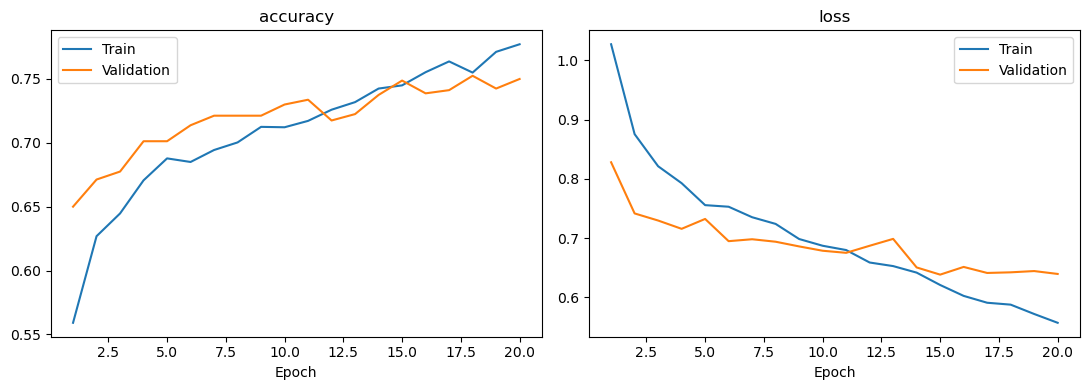

In [6]:
history = pd.read_csv(RESULT_DIR / 'training_history.csv')
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric in zip(axes, ['accuracy', 'loss']):
    ax.plot(history['epoch'] + 1, history[metric], label='Train')
    ax.plot(history['epoch'] + 1, history['val_' + metric], label='Validation')
    ax.set(xlabel='Epoch', title=metric)
    ax.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / 'accuracy_loss_curves.png', dpi=150)
plt.show()

## Bước 5 – Đánh giá trên tập test

Nạp model tốt nhất rồi đánh giá trên test. Accuracy cho biết tỷ lệ dự đoán đúng; macro F1 là trung bình F1 của 4 lớp.

Confusion matrix có hàng là nhãn thật, cột là dự đoán. Xem thêm hai chiều nhầm smoke ↔ smokefire. Test chỉ dùng để báo cáo sau khi chọn model bằng validation.

,precision,recall,f1-score,support
fire,0.7532,0.5950,0.6648,200.0000
nofire,0.6681,0.7650,0.7133,200.0000
smoke,0.5387,0.8000,0.6439,200.0000
smokefire,0.4310,0.2500,0.3165,200.0000
accuracy,0.6025,0.6025,0.6025,0.6025
macro avg,0.5978,0.6025,0.5846,800.0000
weighted avg,0.5978,0.6025,0.5846,800.0000


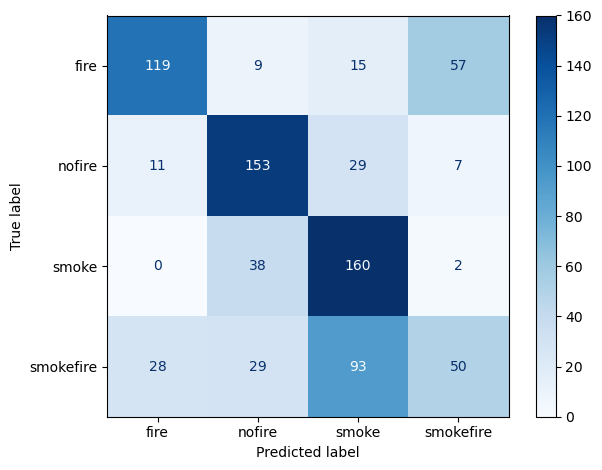

Accuracy: 60.25% | Macro F1: 0.5846
smokefire → smoke: 93 | smoke → smokefire: 2


In [7]:
best_model = tf.keras.models.load_model(MODEL_PATH)
loss, accuracy = best_model.evaluate(test_ds, verbose=0)
probabilities = best_model.predict(test_ds, verbose=0)
y_true = test_df['class_index'].to_numpy()
y_pred = probabilities.argmax(axis=1)
assert np.isclose(accuracy, (y_true == y_pred).mean())
report = classification_report(y_true, y_pred, labels=range(len(CLASS_NAMES)),
    target_names=CLASS_NAMES, output_dict=True, zero_division=0)
matrix = confusion_matrix(y_true, y_pred, labels=range(len(CLASS_NAMES)))
display(pd.DataFrame(report).T.round(4))
ConfusionMatrixDisplay(matrix, display_labels=CLASS_NAMES).plot(cmap='Blues')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'confusion_matrix.png', dpi=150)
plt.show()
print(f'Accuracy: {accuracy:.2%} | Macro F1: {report["macro avg"]["f1-score"]:.4f}')
print('smokefire → smoke:', matrix[3, 2], '| smoke → smokefire:', matrix[2, 3])

## Bước 6 – Lưu kết quả

Lưu metrics, dự đoán từng ảnh, danh sách ảnh sai và confusion matrix tại `results/basic_nn_transfer_preprocessing/`. Checkpoint được lưu tại `models/basic_nn_transfer_preprocessing.keras`.

In [8]:
predictions = test_df[['filepath', 'processed_filepath', 'label', 'class_index']].copy()
predictions['predicted_label'] = np.array(CLASS_NAMES)[y_pred]
predictions['confidence'] = probabilities.max(axis=1)
predictions.to_csv(RESULT_DIR / 'predictions.csv', index=False)
predictions[y_true != y_pred].to_csv(RESULT_DIR / 'misclassified.csv', index=False)
pd.DataFrame(report).T.to_csv(RESULT_DIR / 'classification_report.csv', index_label='class')
pd.DataFrame(matrix, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(
    RESULT_DIR / 'confusion_matrix.csv', index_label='true_label')

metrics = {
    'test_accuracy': float(accuracy), 'test_loss': float(loss),
    'macro_f1': report['macro avg']['f1-score'],
    'misclassified_count': int((y_true != y_pred).sum()),
    'parameter_count': best_model.count_params(),
    'best_epoch': int(history['val_loss'].argmin()) + 1,
    'best_val_loss': float(history['val_loss'].min()),
    'class_names': CLASS_NAMES, 'image_size': list(IMAGE_SIZE), 'seed': SEED,
    'preprocessing': {'source': 'processed_filepath', 'manifest': 'data/split.csv',
        'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225],
        'resize': 'bilinear, antialias=True', 'augmentation': 'horizontal_flip'},
    'training_config': {'dense_units': [256, 128], 'dropout': [0.3, 0.2],
        'learning_rate': 3e-4, 'batch_size': BATCH_SIZE, 'epochs': EPOCHS},
    'tensorflow_version': tf.__version__,
}
(RESULT_DIR / 'metrics.json').write_text(json.dumps(metrics, indent=2), encoding='utf-8')
MODEL_PATH.with_suffix('.labels.json').write_text(json.dumps(CLASS_NAMES), encoding='utf-8')


40